<a href="https://colab.research.google.com/github/Avicenna-zzz/Datmin/blob/main/kmeans_clustering_TKA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Clustering — Nilai Akademik Siswa
**Alur:** Load Data → EDA → Preprocessing → Elbow Method → Clustering → Evaluasi → Visualisasi → Simpan

## Step 1 — Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

pd.set_option('display.float_format', '{:.2f}'.format)
print('Library berhasil diimpor')

Library berhasil diimpor


## Step 2 — Load Data

In [2]:
# Upload file di Google Colab (hapus tanda # jika belum upload)
# from google.colab import files
# files.upload()

In [3]:
df = pd.read_csv('data_lengkap_kmeans.csv')
print(f'Ukuran data: {df.shape[0]} baris x {df.shape[1]} kolom')
df.head()

Ukuran data: 125 baris x 7 kolom


,No,Nama,Bahasa_Indonesia,Matematika,Bahasa_Inggris,Nilai_Pilihan1,Nilai_Pilihan2
0,1,Mustaghfirin,43.70,25.05,19.03,51.78,25.94
1,2,Moh. Amin Sholeh,59.66,60.90,19.37,38.87,25.82
2,3,MUKHAMAD RAIKHAN GIFARI,52.78,35.75,27.42,27.84,45.72
3,4,ACHSAN BUKHORI,57.69,23.63,22.13,57.47,31.00
4,5,FATKUL MUNIR,77.92,57.43,30.90,33.86,81.23


## Step 3 — Eksplorasi Data (EDA)

In [4]:
df.describe()

,No,Bahasa_Indonesia,Matematika,Bahasa_Inggris,Nilai_Pilihan1,Nilai_Pilihan2
count,125.00,123.00,123.00,123.00,123.00,123.00
mean,63.00,57.33,33.84,21.10,47.59,35.72
std,36.23,10.20,11.00,8.58,12.73,13.22
min,1.00,36.46,5.00,5.00,5.00,5.00
25%,32.00,50.16,25.77,18.37,40.38,29.04
50%,63.00,56.15,33.39,23.08,48.58,36.02
75%,94.00,64.72,41.24,26.91,55.72,44.86
max,125.00,81.17,60.90,41.33,74.69,81.23


In [5]:
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
No                  0
Nama                0
Bahasa_Indonesia    2
Matematika          2
Bahasa_Inggris      2
Nilai_Pilihan1      2
Nilai_Pilihan2      2
dtype: int64


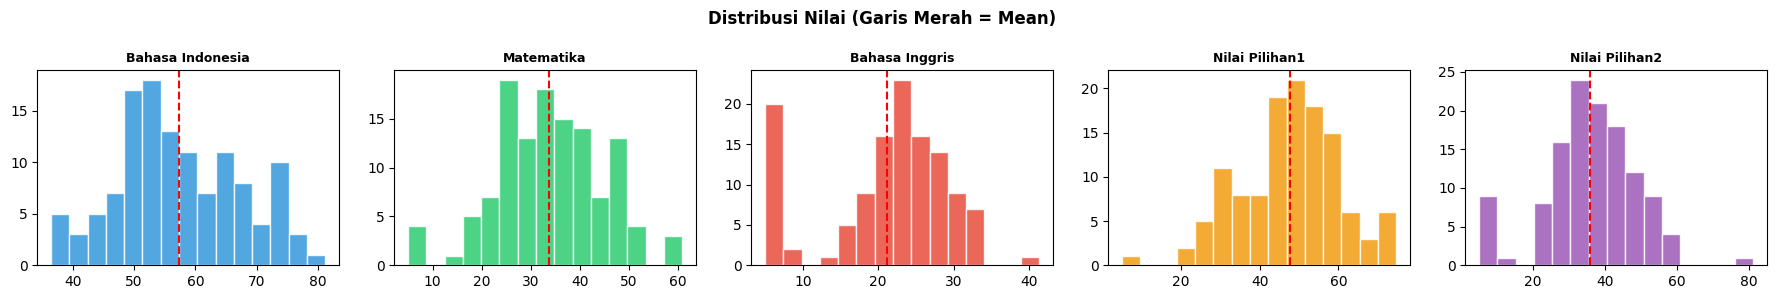

In [6]:
features = ['Bahasa_Indonesia', 'Matematika', 'Bahasa_Inggris', 'Nilai_Pilihan1', 'Nilai_Pilihan2']
palette  = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for feat, ax, color in zip(features, axes, palette):
    ax.hist(df[feat].dropna(), bins=15, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[feat].mean(), color='red', ls='--', lw=1.5)
    ax.set_title(feat.replace('_', ' '), fontsize=9, fontweight='bold')

plt.suptitle('Distribusi Nilai (Garis Merah = Mean)', fontweight='bold')
plt.tight_layout()
plt.show()

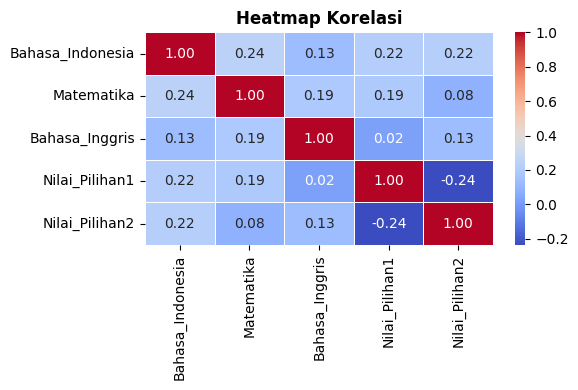

In [7]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4 — Preprocessing

| Langkah | Metode |
|---|---|
| Imputasi missing values | Median (robust terhadap outlier) |
| Normalisasi | StandardScaler — z-score (wajib untuk K-Means berbasis jarak) |

In [8]:
# Imputasi median
df_feat = df[features].copy()
for col in features:
    df_feat[col] = df_feat[col].fillna(df_feat[col].median())

print('Missing values setelah imputasi:')
print(df_feat.isnull().sum())

Missing values setelah imputasi:
Bahasa_Indonesia    0
Matematika          0
Bahasa_Inggris      0
Nilai_Pilihan1      0
Nilai_Pilihan2      0
dtype: int64


In [9]:
# Normalisasi
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_feat.values)

print('Statistik setelah normalisasi (mean=0, std=1):')
pd.DataFrame(X_scaled, columns=features).describe().round(3)

Statistik setelah normalisasi (mean=0, std=1):


,Bahasa_Indonesia,Matematika,Bahasa_Inggris,Nilai_Pilihan1,Nilai_Pilihan2
count,125.00,125.00,125.00,125.00,125.00
mean,0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00
min,-2.07,-2.65,-1.90,-3.39,-2.35
25%,-0.71,-0.71,-0.30,-0.56,-0.49
50%,-0.12,-0.04,0.23,0.08,0.02
75%,0.71,0.67,0.66,0.63,0.70
max,2.37,2.49,2.38,2.15,3.48


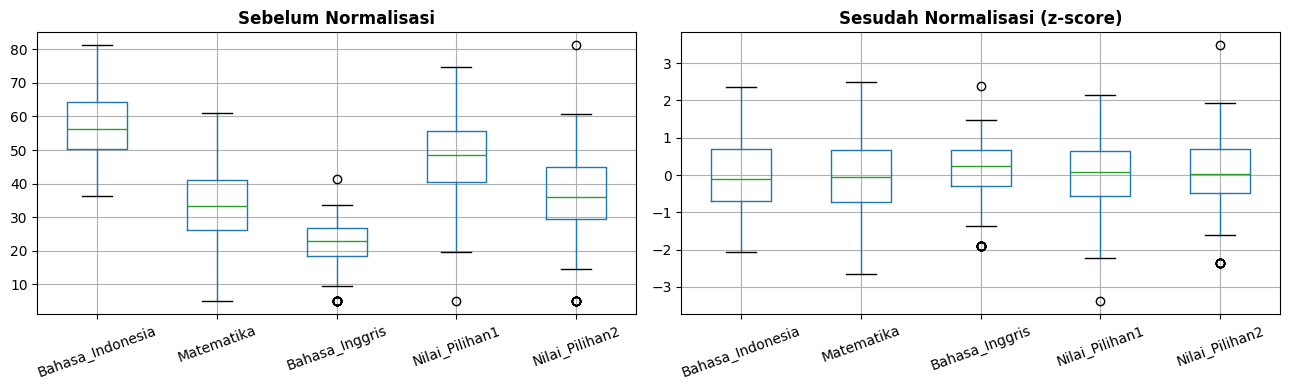

In [10]:
# Perbandingan sebelum vs sesudah
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

df_feat.boxplot(ax=ax1)
ax1.set_title('Sebelum Normalisasi', fontweight='bold')
ax1.tick_params(axis='x', rotation=20)

pd.DataFrame(X_scaled, columns=features).boxplot(ax=ax2)
ax2.set_title('Sesudah Normalisasi (z-score)', fontweight='bold')
ax2.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Step 5 — Menentukan K Optimal (Elbow Method)

Elbow Method memplot nilai **WCSS** (Within-Cluster Sum of Squares) untuk berbagai nilai k. Titik **"siku"** pada grafik menunjukkan k optimal, yaitu di mana penambahan cluster tidak lagi signifikan mengurangi WCSS.

In [11]:
# Hitung inertia k=2 sampai 10
inertias = []
K_range  = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f'  k={k:2d} | WCSS: {km.inertia_:.2f}')

  k= 2 | WCSS: 499.18
  k= 3 | WCSS: 416.03
  k= 4 | WCSS: 350.14
  k= 5 | WCSS: 311.55
  k= 6 | WCSS: 281.93
  k= 7 | WCSS: 263.85
  k= 8 | WCSS: 243.49
  k= 9 | WCSS: 225.24
  k=10 | WCSS: 217.23


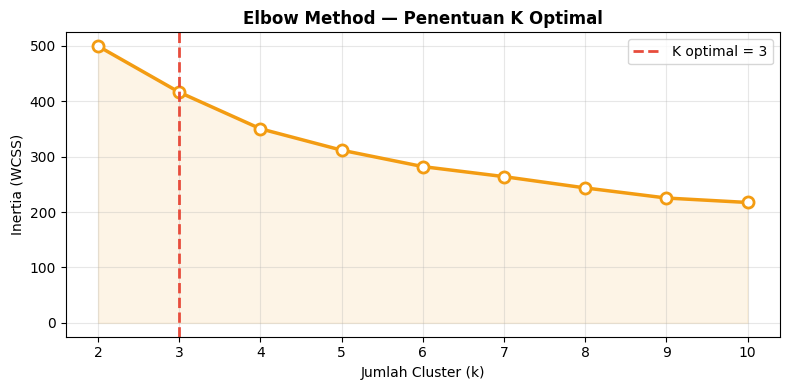

K optimal yang dipilih: 3


In [12]:
K_OPTIMAL = 3   # ubah jika diperlukan

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, 'o-', color='#f39c12', lw=2.5, ms=8,
         markerfacecolor='white', markeredgewidth=2)
plt.axvline(K_OPTIMAL, color='#e74c3c', ls='--', lw=2, label=f'K optimal = {K_OPTIMAL}')
plt.fill_between(list(K_range), inertias, alpha=0.1, color='#f39c12')
plt.title('Elbow Method — Penentuan K Optimal', fontweight='bold')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia (WCSS)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'K optimal yang dipilih: {K_OPTIMAL}')

## Step 6 — K-Means Clustering

In [13]:
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10, max_iter=300)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f'Iterasi konvergen : {kmeans.n_iter_}')
print(f'Inertia akhir     : {kmeans.inertia_:.2f}')
print()
print('Distribusi per cluster:')
print(df['Cluster'].value_counts().sort_index())

Iterasi konvergen : 10
Inertia akhir     : 416.03

Distribusi per cluster:
Cluster
0    41
1    56
2    28
Name: count, dtype: int64


In [14]:
# Centroid dalam skala asli
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
centroids.index.name = 'Cluster'
centroids.round(2)

,Bahasa_Indonesia,Matematika,Bahasa_Inggris,Nilai_Pilihan1,Nilai_Pilihan2
Cluster,,,,,
0,62.35,42.23,25.54,57.97,33.78
1,52.53,28.30,16.08,48.52,31.28
2,59.49,32.60,24.78,30.60,47.48


In [15]:
# Labeling: cluster dengan rata-rata nilai tertinggi = Tinggi, dst.
order     = df.groupby('Cluster')[features].mean().mean(axis=1).sort_values(ascending=False).index.tolist()
label_map = {order[0]: 'Tinggi', order[1]: 'Sedang', order[2]: 'Rendah'}
df['Kategori'] = df['Cluster'].map(label_map)

for cid, lbl in label_map.items():
    print(f'  Cluster {cid} -> {lbl}')
print()
print(df['Kategori'].value_counts())

  Cluster 0 -> Tinggi
  Cluster 2 -> Sedang
  Cluster 1 -> Rendah

Kategori
Rendah    56
Tinggi    41
Sedang    28
Name: count, dtype: int64


In [16]:
# Rata-rata nilai per kategori
df.groupby('Kategori')[features].mean().round(2)

,Bahasa_Indonesia,Matematika,Bahasa_Inggris,Nilai_Pilihan1,Nilai_Pilihan2
Kategori,,,,,
Rendah,52.40,28.11,15.82,48.51,31.10
Sedang,59.49,32.60,24.78,30.60,47.48
Tinggi,62.35,42.23,25.54,57.97,33.78


## Step 7 — Evaluasi Model

| Metrik | Rentang | Ideal |
|---|---|---|
| Silhouette Score | -1 s/d 1 | Mendekati 1 |
| Davies-Bouldin | >= 0 | Mendekati 0 |
| Inertia (WCSS) | >= 0 | Sekecil mungkin |

In [17]:
sil = silhouette_score(X_scaled, df['Cluster'])
db  = davies_bouldin_score(X_scaled, df['Cluster'])

print(f'Silhouette Score : {sil:.4f}')
print(f'Davies-Bouldin   : {db:.4f}')
print(f'Inertia (WCSS)   : {kmeans.inertia_:.2f}')

Silhouette Score : 0.1973
Davies-Bouldin   : 1.5889
Inertia (WCSS)   : 416.03


## Step 8 — Visualisasi Hasil

In [18]:
CAT_COLORS = {'Tinggi': '#2ecc71', 'Sedang': '#3498db', 'Rendah': '#e74c3c'}

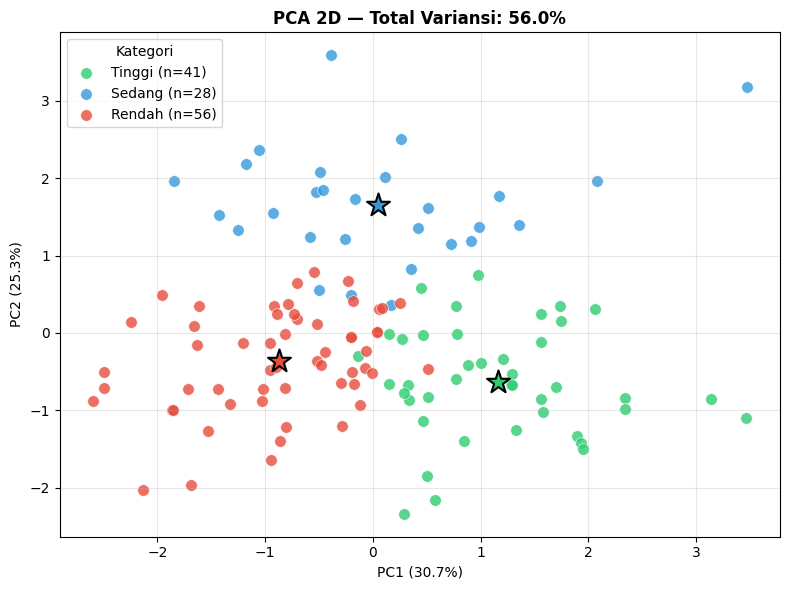

In [19]:
# PCA 2D Scatter
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var   = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(8, 6))
for cat, color in CAT_COLORS.items():
    mask = df['Kategori'] == cat
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color,
                label=f'{cat} (n={mask.sum()})', s=70, alpha=0.8, edgecolors='white', lw=0.5)
for i, center in enumerate(pca.transform(kmeans.cluster_centers_)):
    plt.scatter(*center, marker='*', s=300, c=CAT_COLORS[label_map[i]], edgecolors='black', lw=1.5, zorder=5)

plt.title(f'PCA 2D — Total Variansi: {sum(var):.1f}%', fontweight='bold')
plt.xlabel(f'PC1 ({var[0]:.1f}%)')
plt.ylabel(f'PC2 ({var[1]:.1f}%)')
plt.legend(title='Kategori')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

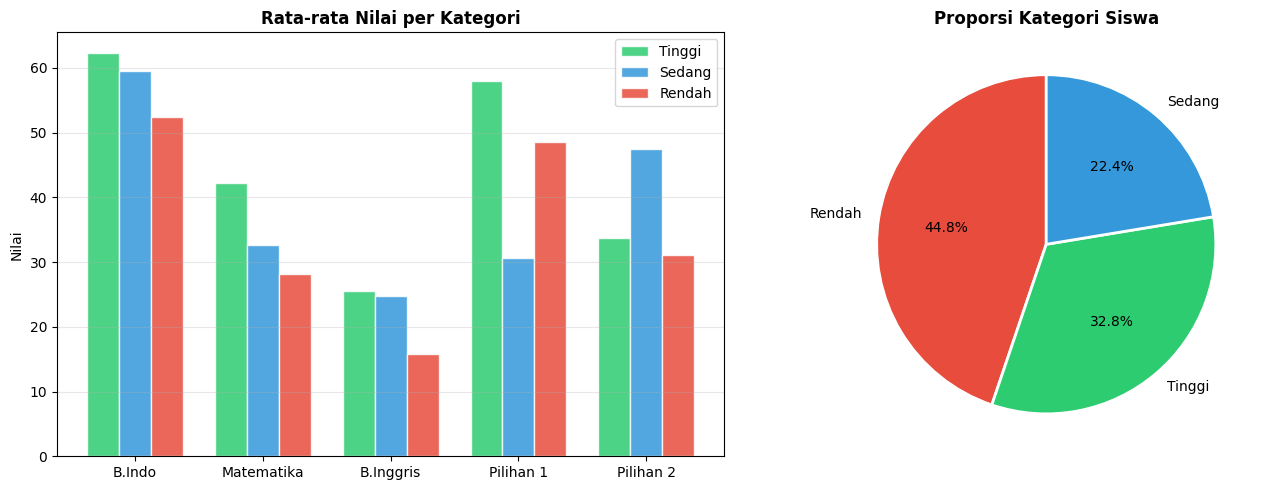

In [20]:
# Grouped bar + Pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(features)); w = 0.25
lbl = ['B.Indo', 'Matematika', 'B.Inggris', 'Pilihan 1', 'Pilihan 2']
for i, cat in enumerate(['Tinggi', 'Sedang', 'Rendah']):
    cid  = [k for k, v in label_map.items() if v == cat][0]
    vals = df.groupby('Cluster')[features].mean().loc[cid].values
    ax1.bar(x + i*w, vals, w, label=cat, color=CAT_COLORS[cat], alpha=0.85, edgecolor='white')
ax1.set_xticks(x + w); ax1.set_xticklabels(lbl)
ax1.set_title('Rata-rata Nilai per Kategori', fontweight='bold')
ax1.set_ylabel('Nilai'); ax1.legend(); ax1.grid(axis='y', alpha=0.3)

cat_count = df['Kategori'].value_counts()
ax2.pie(cat_count.values, labels=cat_count.index,
        colors=[CAT_COLORS[c] for c in cat_count.index],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Proporsi Kategori Siswa', fontweight='bold')

plt.tight_layout()
plt.show()

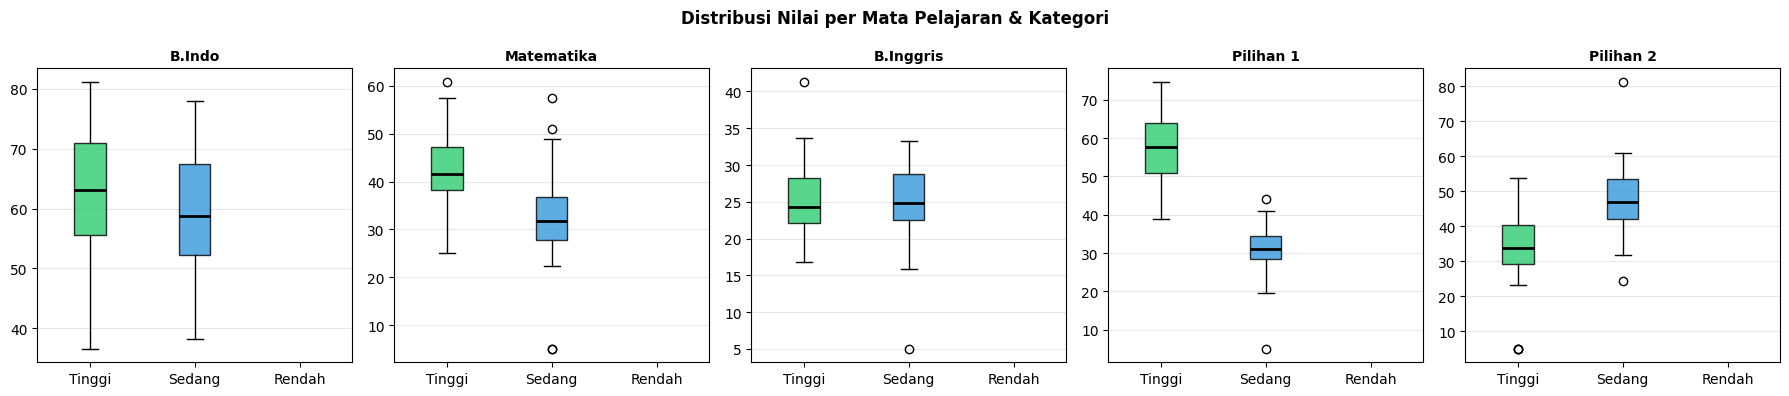

In [21]:
# Boxplot
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
lbl_feat  = ['B.Indo', 'Matematika', 'B.Inggris', 'Pilihan 1', 'Pilihan 2']

for feat, label, ax in zip(features, lbl_feat, axes):
    data = [df[df['Kategori'] == cat][feat].values for cat in ['Tinggi', 'Sedang', 'Rendah']]
    bp   = ax.boxplot(data, patch_artist=True, labels=['Tinggi','Sedang','Rendah'],
                      medianprops={'color':'black','lw':2})
    for patch, cat in zip(bp['boxes'], ['Tinggi','Sedang','Rendah']):
        patch.set_facecolor(CAT_COLORS[cat]); patch.set_alpha(0.8)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribusi Nilai per Mata Pelajaran & Kategori', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 9 — Simpan Hasil

In [22]:
OUTPUT = 'hasil_kmeans.csv'
df[['No', 'Nama'] + features + ['Cluster', 'Kategori']].to_csv(OUTPUT, index=False)
print(f'Tersimpan: {OUTPUT}')
df[['No', 'Nama'] + features + ['Cluster', 'Kategori']].head(10)

Tersimpan: hasil_kmeans.csv


,No,Nama,Bahasa_Indonesia,Matematika,Bahasa_Inggris,Nilai_Pilihan1,Nilai_Pilihan2,Cluster,Kategori
0,1,Mustaghfirin,43.70,25.05,19.03,51.78,25.94,1,Rendah
1,2,Moh. Amin Sholeh,59.66,60.90,19.37,38.87,25.82,0,Tinggi
2,3,MUKHAMAD RAIKHAN GIFARI,52.78,35.75,27.42,27.84,45.72,2,Sedang
3,4,ACHSAN BUKHORI,57.69,23.63,22.13,57.47,31.00,1,Rendah
4,5,FATKUL MUNIR,77.92,57.43,30.90,33.86,81.23,2,Sedang
5,6,MUHAMMAD NURUS SOLEH,51.26,38.29,28.08,47.48,33.03,0,Tinggi
6,7,Muhammad Arja Muna,49.26,23.52,25.88,50.22,20.45,1,Rendah
7,8,Daffasatria Adhi Prasetya,53.03,5.00,26.20,27.18,43.73,2,Sedang
8,9,INDRA MAULANA KURNIAWAN,42.59,42.10,17.91,51.58,20.41,1,Rendah
9,10,MUHAMMAD NABIL FAIZURRAHMAN,49.81,43.49,24.54,34.33,31.93,2,Sedang


In [23]:
# Download file (hapus tanda # jika menggunakan Google Colab)
# from google.colab import files
# files.download(OUTPUT)